# Training Strategies
_Cognizant – Guided Lab Notebook_

**Layout per section:**
1) **Quick guide (above code)** — What this does / What to observe / Why it matters
2) **Code cell** — Runnable demo
3) **Deep dive (below code)** — Detailed code walkthrough with line-by-line intent

**Note:** Do not compare masked vs unmasked loss magnitudes directly; masked loss can be numerically higher but is the only meaningful metric to track over time.

### Quick guide — Environment checks
- **What this does:** Checks if PyTorch and PEFT are available.
- **What to observe:** `{'torch': bool, 'peft': bool, 'python': 'X.Y.Z'}`.
- **Why it matters:** Optional adapter demos require these libraries; core notebook runs without them.

In [1]:
import importlib, sys
HAS_TORCH = importlib.util.find_spec('torch') is not None
HAS_PEFT = importlib.util.find_spec('peft') is not None
print({'torch': HAS_TORCH, 'peft': HAS_PEFT, 'python': sys.version})

{'torch': True, 'peft': True, 'python': '3.11.11 (main, Dec  3 2024, 17:20:40) [Clang 16.0.0 (clang-1600.0.26.4)]'}


#### Deep dive — Environment checks: Code walkthrough
- `importlib.util.find_spec('torch')` tests importability **without** importing; returns a module spec or `None`.
- We store booleans `HAS_TORCH`/`HAS_PEFT` to gate optional sections.
- `sys.version` printed for reproducibility when students report issues.

## 1. Data I/O – Tokenize → Pad → Mask → Batch
**Quick guide**
- **What this does:** Build a mini vocabulary, tokenize sentences, right-pad to equal length, and create a PAD mask.
- **What to observe:** Shapes of `padded` and `mask`; `mask` shows 1s for real tokens, 0s for padding.
- **Why it matters:** Sequence models need uniform shapes; losses must respect masking.

In [2]:
# Build tiny vocab, tokenize, pad, and create a PAD mask
from collections import defaultdict
def build_vocab(texts, min_freq=1):
    freq = defaultdict(int)
    for t in texts:
        for tok in t.strip().split():
            freq[tok]+=1
    vocab = {'[PAD]':0,'[UNK]':1,'[EOS]':2}
    for tok,c in freq.items():
        if c>=min_freq and tok not in vocab:
            vocab[tok]=len(vocab)
    return vocab

def tokenize(text, vocab):
    return [vocab.get(tok,1) for tok in text.strip().split()] + [vocab['[EOS]']]

def pad_batch(batch_ids, pad_id=0):
    maxlen = max(len(x) for x in batch_ids)
    padded, mask = [], []
    for ids in batch_ids:
        pad_len = maxlen - len(ids)
        padded.append(ids + [pad_id]*pad_len)
        mask.append([1]*len(ids) + [0]*pad_len)
    return padded, mask

texts = [
  'vpn down hr floor users cannot login',
  'reset password portal error',
  'new hire laptop not provisioning',
]
vocab = build_vocab(texts)
batch_ids = [tokenize(t, vocab) for t in texts]
padded, mask = pad_batch(batch_ids)
print('vocab size:', len(vocab))
print('batch shape:', (len(padded), len(padded[0])))
print('padded[0]:', padded[0])
print('mask[0]:', mask[0])

vocab size: 19
batch shape: (3, 8)
padded[0]: [3, 4, 5, 6, 7, 8, 9, 2]
mask[0]: [1, 1, 1, 1, 1, 1, 1, 1]


#### Deep dive — Data I/O: Code walkthrough
- **`build_vocab`** scans all words and builds a mapping; reserves `0:[PAD]`, `1:[UNK]`, `2:[EOS]`.
- **`tokenize`** maps each word via `vocab.get(tok, 1)` so unknowns become `[UNK]=1`; appends `[EOS]` to mark sequence end.
- **`pad_batch`** finds the batch's `maxlen`; right-pads shorter sequences with `[PAD]=0` and creates a `mask` with 1s on real tokens and 0s on pads.
- The outputs `padded`/`mask` have identical shapes `B×T` and are used in all sequence losses/metrics.

### 1A. Contrastive Loss — Bad vs Good
**Quick guide**
- **What this does:** Compares an unmasked loss (includes PADs) vs a masked loss (excludes PADs).
- **What to observe:** Unmasked loss can look artificially low, because the model easily guesses the "right values", as many of them are not real tokens, but just the "PAD" code; masked loss may be higher but is the only reliable metric, because the model can only work from real tokens, not artificial "PAD" values srpinkled everywhere.
- **Why it matters:** Training on PADs corrupts gradients and makes progress look better than it is.

In [3]:
# BAD: loss computed over PAD tokens (mask ignored)
import numpy as np
np.random.seed(0)
logits = np.random.randn(len(padded), len(padded[0]))  # fake logits
targets = np.array(padded)
loss_bad = float(np.mean((logits - targets)**2))
loss_bad

87.04444049513734

#### Deep dive — Bad loss: Code walkthrough
- `logits` simulates a model output matrix `B×T`.
- `targets` reuses token IDs as pseudo-targets for demonstration.
- `np.mean((logits-targets)**2)` **averages over PAD positions** as well, diluting real errors.
- Consequence: numeric value may be **smaller** yet is **misleading and not comparable** across batches with different padding.

In [4]:
# GOOD: masked loss excludes PAD tokens
arr_logits = np.array(logits)
arr_targets = np.array(targets)
arr_mask = np.array(mask)
num = np.sum(((arr_logits - arr_targets)**2) * arr_mask)
den = np.sum(arr_mask) + 1e-9
loss_good = float(num/den)
loss_good

109.86554499885509

#### Deep dive — Good loss: Code walkthrough
- `arr_mask` holds 1s on true tokens, 0s on pads.
- We **zero out** PAD contributions via multiplication before summing.
- Denominator uses the **count of real tokens**; `+1e-9` avoids divide-by-zero.
- Result is a stable, comparable loss that tracks true learning progress.

## 2. Smart Batching — Reduce Padding Waste
**Quick guide**
- **What this does:** Compares random batching vs length-binned batching.
- **What to observe:** When you group batches by segments of about the same length, the system is faster because it does not waste time processing padding tokens added to make the entire batch look consistent in structure. The result is that by grouping segments of the same length into the same batches, you waste less tokens, the training is faster.
- **Why it matters:** Fewer wasted tokens → better throughput at fixed memory.

Avg pad waste (random): 5075.8
Avg pad waste (grouped): 2202.7391304347825


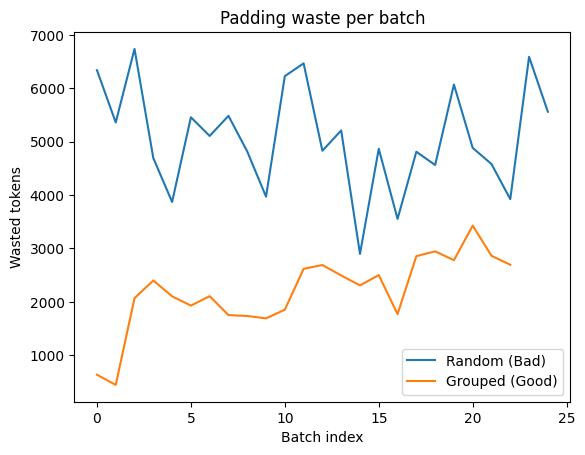

In [5]:
import numpy as np, random
import matplotlib.pyplot as plt
np.random.seed(42)
lengths = np.random.randint(20, 1024, size=300)
batch_size = 12
def pad_waste(batch):
    m = max(batch)
    return sum(m - x for x in batch)
# Random batches (Bad)
random_batches = [lengths[i:i+batch_size] for i in range(0,len(lengths),batch_size)]
waste_bad = [pad_waste(list(b)) for b in random_batches]
avg_bad = np.mean(waste_bad)
print('Avg pad waste (random):', float(avg_bad))
# Grouped by length bins (Good)
bins = [[],[],[]]
for L in lengths:
    if L<=128: bins[0].append(L)
    elif L<=512: bins[1].append(L)
    else: bins[2].append(L)
grouped = []
for b in bins:
    random.shuffle(b)
    grouped += [b[i:i+batch_size] for i in range(0,len(b),batch_size)]
waste_good = [pad_waste(list(b)) for b in grouped if len(b)==batch_size]
avg_good = np.mean(waste_good)
print('Avg pad waste (grouped):', float(avg_good))
plt.figure()
plt.title('Padding waste per batch')
plt.plot(waste_bad, label='Random (Bad)')
plt.plot(waste_good, label='Grouped (Good)')
plt.xlabel('Batch index')
plt.ylabel('Wasted tokens')
plt.legend()
plt.show()

#### Deep dive — Smart batching: Code walkthrough
- `lengths` simulates token counts; waste per batch equals `max(lengths_in_batch) - length_i` summed.
- Random batching ignores length; binned batching keeps similar lengths together → lower `max` in each batch.
- Plot lets you visually compare per-batch waste across strategies.

## 3. Keeping the Pipe Full — Tokens/sec & Prefetch
**Quick guide**
- **What this does:** Simulates overlapping data loading with GPU compute.
- **What to observe:** With `prefetch=True`, the system loads the next batch while training on the previous batch is still ongoing. The result is a faster load time, and thus a fastter training (more tokens per second). By contrast, if you wait for a training pass on one batch to be completed before loading the next batch, loading + training takes longer (and thus you get a lower token per second speed).
- **Why it matters:** Keeps accelerators busy by hiding input latency behind compute.

In [7]:
import time
import numpy as np
def simulate_epoch(batches=200, loader_latency=0.004, compute_time=0.002, prefetch=False):
    start = time.time()
    queued = 0
    for _ in range(batches):
        if not (prefetch and queued>0):
            time.sleep(loader_latency)
        time.sleep(compute_time)
        queued = 1 if prefetch else 0
    dur = time.time()-start
    tokens_per_batch = 512*32
    tps = (tokens_per_batch*batches)/max(dur,1e-9)
    return dur, tps
d1, t1 = simulate_epoch(prefetch=False)
d2, t2 = simulate_epoch(prefetch=True)
print({'no_prefetch': {'sec': round(d1,3), 'tokens_per_sec': int(t1)},
       'prefetch':    {'sec': round(d2,3), 'tokens_per_sec': int(t2)}})

{'no_prefetch': {'sec': 1.459, 'tokens_per_sec': 2246567}, 'prefetch': {'sec': 0.501, 'tokens_per_sec': 6543366}}


#### Deep dive — Prefetch: Code walkthrough
- **Arguments**: `loader_latency` ≈ I/O + tokenization + collation + H2D copy; `compute_time` ≈ GPU step time.
- **No prefetch**: each iteration blocks on `loader_latency` then runs compute → per-batch ~ `loader+compute`.
- **Prefetch**: after first batch, we set `queued=1` to indicate the next batch was prepared **during** compute; subsequent iterations often skip the loader wait.
- **Throughput**: `tokens_per_batch*batches / dur` increases when overlapping eliminates idle GPU time.

### Bonus — I/O-bound vs Compute-bound (prefetch effectiveness)
**Quick guide**
- **What this does:** Compares tokens/sec with and without prefetch for two regimes.
- **What to observe:** Bigger prefetch gains when `loader_latency` ≫ `compute_time` (I/O-bound).

IO_bound {'no_prefetch': {'sec': 1.934, 'tps': 1694484}, 'prefetch': {'sec': 0.5, 'tps': 6558334}}
Compute_bound {'no_prefetch': {'sec': 1.932, 'tps': 1696385}, 'prefetch': {'sec': 1.432, 'tps': 2289064}}


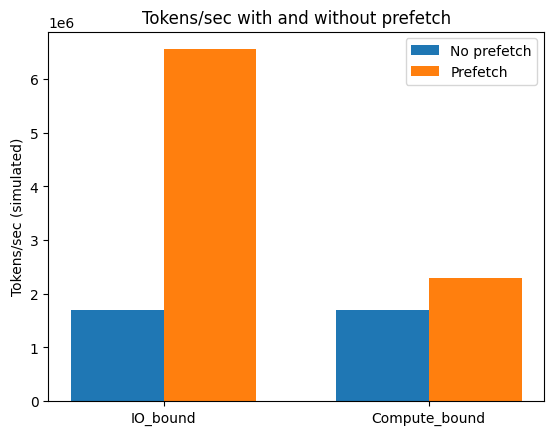

In [8]:
import numpy as np
import matplotlib.pyplot as plt
scenarios = [
    ('IO_bound', 0.006, 0.002),
    ('Compute_bound', 0.002, 0.006),
]
labels, tps_no, tps_yes = [], [], []
for name, L, C in scenarios:
    d_no, t_no = simulate_epoch(loader_latency=L, compute_time=C, prefetch=False)
    d_yes, t_yes = simulate_epoch(loader_latency=L, compute_time=C, prefetch=True)
    labels.append(name)
    tps_no.append(t_no)
    tps_yes.append(t_yes)
    print(name, {
        'no_prefetch': {'sec': round(d_no,3), 'tps': int(t_no)},
        'prefetch':    {'sec': round(d_yes,3), 'tps': int(t_yes)},
    })
x = np.arange(len(labels))
width = 0.35
plt.figure()
plt.title('Tokens/sec with and without prefetch')
plt.bar(x - width/2, tps_no, width, label='No prefetch')
plt.bar(x + width/2, tps_yes, width, label='Prefetch')
plt.xticks(x, labels)
plt.ylabel('Tokens/sec (simulated)')
plt.legend()
plt.show()

#### Deep dive — I/O-bound vs Compute-bound: Code walkthrough
- We run two scenarios with two different Loader latency (L) and Compute time (C) values: `(L=6ms, C=2ms)` and `(L=2ms, C=6ms)`.
- For each, we compute tokens/sec with and without prefetch, print the numbers, and show a bar chart.
- Interpretation: large gains when I/O dominates; minimal gains when compute dominates.

## 4. Unknown-Token Rate — Detect Tokenizer Mismatches
**Quick guide**
- **What this does:** Computes how often tokens become `[UNK]` under a **wrong** vs **correct** vocab.
- **What to observe:** `unk_rate_bad` high; `unk_rate_good` near zero.
- **Why it matters:** Always pair a model with the tokenizer it was trained with.

In [9]:
# Simulate tokenizer mismatch via a wrong vocabulary
bad_vocab = {'[PAD]':0,'[UNK]':1,'[EOS]':2,'reset':3,'password':4}
def unk_rate(texts, vocab):
    unk = tot = 0
    for t in texts:
        for w in t.split()+['[EOS]']:
            tot += 1
            if w not in vocab:
                unk += 1
    return unk/max(tot,1)
r_bad = unk_rate(texts, bad_vocab)
r_good = unk_rate(texts, vocab)
print({'unk_rate_bad': round(r_bad,3), 'unk_rate_good': round(r_good,3)})

{'unk_rate_bad': 0.737, 'unk_rate_good': 0.0}


#### Deep dive — Tokenizer mismatch: Code walkthrough
- In **Cell 1**, we ran training on 3 example sentences, and built the tokenizer vocabulary from these sentences `vocab = build_vocab(texts)`. When the tokenizer in training is the same as the tokenizer at inference time, the model recognizes all words; by contrast in this cell we intentionally use **`bad_vocab`** with only a couple of entries.
- When parsing the same `texts`, most words are **absent** in `bad_vocab`, so they map to `[UNK]` → high `unk_rate`.
- `unk_rate` appends `[EOS]` as a sentinel token per sentence to reflect typical tokenizers that add special tokens.

## 5. Learning Rate Schedule — Warmup & Decay
**Quick guide**
- **What this does:** Plots warmup+cosine decay vs a flat, too-high LR.
- **What to observe:** Warmup smooths early optimization; flat high LR risks divergence/plateaus. This is just a representation, refer to LR_schedule notebook to see the effect of this difference in action.
- **Why it matters:** LR schedules are a high-leverage stability tool.

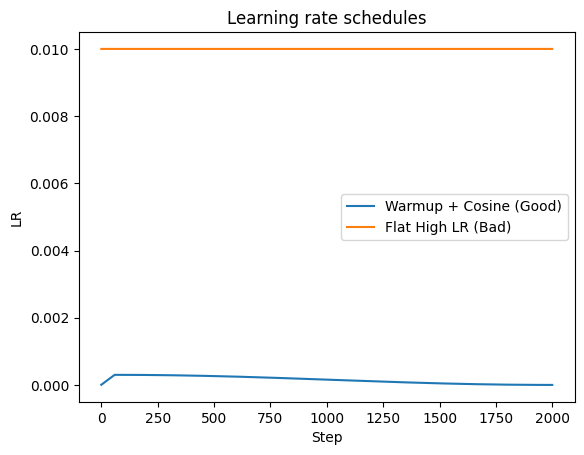

In [10]:
import numpy as np, matplotlib.pyplot as plt
steps = 2000
warmup = int(0.03*steps)
base_lr = 3e-4
lr = []
for s in range(steps):
    if s < warmup:
        lr.append(base_lr * (s+1)/max(1,warmup))
    else:
        pct = (s-warmup)/max(1,steps-warmup)
        lr.append(0.5*base_lr*(1+np.cos(np.pi*pct)))
bad_lr = [1e-2]*steps
plt.figure()
plt.title('Learning rate schedules')
plt.plot(lr, label='Warmup + Cosine (Good)')
plt.plot(bad_lr, label='Flat High LR (Bad)')
plt.xlabel('Step')
plt.ylabel('LR')
plt.legend()
plt.show()

#### Deep dive — LR schedules: Code walkthrough
- **Warmup** grows LR linearly over the first 3% of steps to avoid large, unstable updates at initialization.
- **Cosine decay**: the LR then follows `0.5*base*(1+cos(pi*p))`, smoothly approaching near-zero.
- The **Bad** baseline fixes LR at `1e-2` to illustrate how an overly high constant LR can cause noisy training.

## 6. Token Budget & Run-Plan Calculator
**Quick guide**
- **What this does:** Estimates tokens/step, steps to reach a token budget, and approximate wall-clock given tokens/sec.
- **What to observe:** Increasing Effective Batch Size or sequence length reduces required steps. For example, for sequence of lenght 2048 and an EBS of 512, you need 1048576 steps. If your training set has 50B tokens, this represents 47684 steps.
- **Why it matters:** Enables realistic scheduling and cost estimates.

In [13]:
import numpy as np
def tokens_per_step(seq_len, effective_batch):
    return seq_len * effective_batch
def steps_needed(total_tokens, tokens_per_step):
    return int(np.ceil(total_tokens / max(1,tokens_per_step)))
def time_seconds(steps, tokens_per_step, tokens_per_sec):
    return (steps * tokens_per_step) / max(1,tokens_per_sec)
print(tokens_per_step(2048, 512))
print(steps_needed(50_000_000_000, tokens_per_step(2048,512)))

1048576
47684


#### Deep dive — Budgeting: Code walkthrough
- `tokens_per_step = seq_len × EBS`; higher values mean fewer optimizer steps needed.
- `steps_needed` uses ceiling division to ensure you cover your target token budget.
- `time_seconds` converts token throughput to wall-clock; change assumptions to see schedule sensitivity.

## 6A. Example ETA & Cost planning — scenario table (edit assumptions to try your own)
- **token_budget:** total target tokens
- **seq_len:** tokens per sequence
- **EBS:** effective batch size per optimizer step
- **tokens_per_sec:** cluster throughput
- **cluster_hourly_cost:** $/hr for the whole cluster

In [19]:
import numpy as np, pandas as pd
from math import ceil

# ---- Assumptions (edit me) ----
token_budget = 50_000_000_000      # 50B tokens
seq_len      = 2048                 # tokens per sequence
cluster_hourly_cost = 40.0          # $/hr for the whole cluster

scenarios = [
    # name,           EBS,   tokens_per_sec (cluster)
    ("Baseline",       512,   2_000_000),
    ("Prefetch On",    512,   5_000_000),
    ("Bigger EBS",    1024,   5_000_000),
    ("Aggressive",    1536,  10_000_000),
]

rows = []
for name, EBS, tps in scenarios:
    tokens_per_step = seq_len * EBS
    steps = int(ceil(token_budget / max(1, tokens_per_step)))
    seconds = steps * tokens_per_step / max(1, tps)
    hours = seconds / 3600.0
    cost = hours * cluster_hourly_cost
    rows.append({
        'scenario': name,
        'seq_len': seq_len,
        'EBS': EBS,
        'tok/sec (M)': round(tps/1e6, 2),
        'tokens/step': tokens_per_step,
        'steps': steps,
        'ETA (hours)': round(hours, 2),
        'Est. Cost ($)': round(cost, 2),
    })

df = pd.DataFrame(rows)
display(df)
df

,scenario,seq_len,EBS,tok/sec (M),tokens/step,steps,ETA (hours),Est. Cost ($)
0,Baseline,2048,512,2.0,1048576,47684,6.94,277.78
1,Prefetch On,2048,512,5.0,1048576,47684,2.78,111.11
2,Bigger EBS,2048,1024,5.0,2097152,23842,2.78,111.11
3,Aggressive,2048,1536,10.0,3145728,15895,1.39,55.56


,scenario,seq_len,EBS,tok/sec (M),tokens/step,steps,ETA (hours),Est. Cost ($)
0,Baseline,2048,512,2.0,1048576,47684,6.94,277.78
1,Prefetch On,2048,512,5.0,1048576,47684,2.78,111.11
2,Bigger EBS,2048,1024,5.0,2097152,23842,2.78,111.11
3,Aggressive,2048,1536,10.0,3145728,15895,1.39,55.56


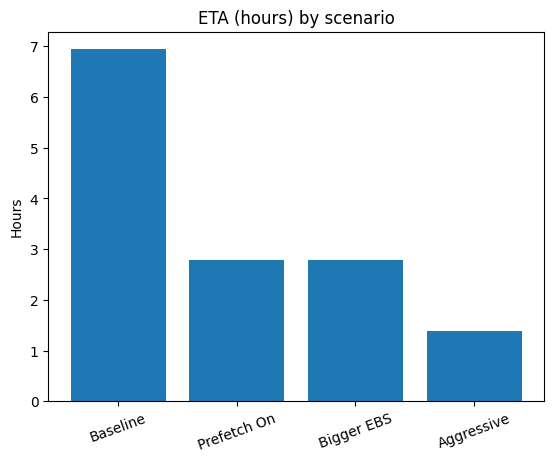

In [20]:
# (Optional) Tiny bar chart for the ETA comparison
import matplotlib.pyplot as plt
plt.figure()
plt.title('ETA (hours) by scenario')
plt.bar(df['scenario'], df['ETA (hours)'])
plt.xticks(rotation=20)
plt.ylabel('Hours')
plt.show()

## 6B. Quick what-if helper
Use `plan_run(...)` to compute ETA & cost for any single configuration.

In [21]:
from math import ceil
def plan_run(token_budget, seq_len, EBS, tokens_per_sec, cluster_hourly_cost):
    tokens_per_step = seq_len * EBS
    steps = int(ceil(token_budget / max(1, tokens_per_step)))
    seconds = steps * tokens_per_step / max(1, tokens_per_sec)
    hours = seconds / 3600.0
    cost = hours * cluster_hourly_cost
    return {
        'tokens_per_step': tokens_per_step,
        'steps': steps,
        'ETA_hours': round(hours, 2),
        'Est_Cost_$': round(cost, 2)
    }

# Example: edit these numbers to your cluster/settings
plan_run(
    token_budget=50_000_000_000,
    seq_len=4096,
    EBS=512,
    tokens_per_sec=8_000_000,
    cluster_hourly_cost=40.0,
)

{'tokens_per_step': 2097152,
 'steps': 23842,
 'ETA_hours': 1.74,
 'Est_Cost_$': 69.44}

## 7. Teacher Forcing vs Inference — Exposure Bias (Toy Bigram)
**Quick guide**
- **What this does:** Builds bigram probabilities then rolls out sequences by conditioning on model outputs. For each bigram value (a, or b), the cell outputs the probability of the value of the next bigram (e.g., given that the current bigram is a, what is the probability that the next bigram will be a, what is the probability that it will be b)
- **What to observe:** The probabilities should be the same when you run the cell several times. However, the predicted letters (in [] brackets, below the probabilities) can change when you run the cell several times, because of sampling randomness. This shows that low validation loss does not guarantee great generation at inference time, because the model is judged diring training/validation on gold contexts (teacher forcing), but at inference it must stand on its own outputs. 
- **Why it matters:** Explains why perplexity ≠ generation quality.

In [8]:
from collections import Counter, defaultdict
corpus = 'a a b a b b a a a b'.split()
bigrams = list(zip(corpus, corpus[1:]))
counts = defaultdict(Counter)
for x,y in bigrams:
    counts[x][y]+=1
def next_token_prob(x):
    c = counts.get(x, Counter())
    tot = sum(c.values())
    return {k:v/max(1,tot) for k,v in c.items()}
print('P(next|a)=', next_token_prob('a'))
print('P(next|b)=', next_token_prob('b'))
import random
def rollout(start='a', steps=8):
    out=[start]
    for _ in range(steps):
        probs = next_token_prob(out[-1])
        if not probs: out.append('a'); continue
        items = list(probs.items())
        tokens, p = zip(*items)
        out.append(random.choices(tokens, weights=p, k=1)[0])
    return out
rollout()

P(next|a)= {'a': 0.5, 'b': 0.5}
P(next|b)= {'a': 0.6666666666666666, 'b': 0.3333333333333333}


['a', 'a', 'b', 'a', 'b', 'b', 'b', 'a', 'b']

#### Deep dive — Exposure bias: Code walkthrough
- We tally bigrams into `counts[x][y]` then normalize to `P(y|x)`.
- During rollout, predictions **feed back** as inputs; minor errors compound and sequences drift.
- Try modifying the corpus to see how drift changes with different conditional distributions.

## 8. Effective Batch Size (EBS) & Gradient Accumulation
**Quick guide**
- **What this does:** Computes global effective batch size.
- **What to observe:** Increasing accumulation or data-parallel workers increases EBS.
- **Why it matters:** Lets you emulate large batches under memory constraints.

In [33]:
def ebs(micro_batch, accum_steps, data_parallel):
    return micro_batch * accum_steps * data_parallel
print({'EBS_example': ebs(16,4,8)})

{'EBS_example': 512}


#### Deep dive — EBS: Code walkthrough
- Formula: `EBS = micro_batch × accum_steps × data_parallel`. Change the size of the micro bacth (default 16), accumulation steps (default 4) or how many GPUs you run in parallel (default 8) to calculate your own EBS.
- If you double any factor, you double EBS; consider linear LR scaling rules.
- Beware that higher accumulation increases step latency and may affect optimizer dynamics.

# 8.A Effective Batch Size (EBS) Timing Demo
This section shows how you can reach the **same EBS** via different mixes of:
- micro-batch size (per GPU),
- gradient accumulation steps, and
- data-parallel replicas (GPUs),
and how those mixes affect **step latency** and **tokens/sec**.

**Simulation model (toy but instructive):**
- Time per micro-step is proportional to `seq_len × micro_batch × compute_ms_per_token`, adjusted by a simple **utilization model** that improves with larger micro-batches.
- Gradient sync happens **once per optimizer step** (after accumulation), costing `comm_ms_base + comm_ms_log * log2(data_parallel)`.
- **EBS = micro_batch × accum_steps × data_parallel** (per optimizer update).

You can tweak the constants to match your hardware.

In [37]:
# Parameters, tweak these for your system
import math, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# --- Workload & hardware knobs ---
seq_len = 2048                 # tokens per sequence
compute_ms_per_token = 0.002   # ms of compute per token per sample (toy)

# --- Utilization model for micro-batch ---
def util_from_micro(mb):
    # asymptotes from ~0.6 at tiny batch to ~1.0 around mb>=64
    return 0.6 + 0.4 * (1.0 - math.exp(-mb/32.0))

# --- Communication cost for DP all-reduce (once per step) ---
comm_ms_base = 30.0            # base latency per step (ms)
comm_ms_log  = 6.0             # extra ms scaled by log2(data_parallel)

def sync_cost_ms(dp):
    return comm_ms_base + comm_ms_log * math.log2(max(1, dp))

def micro_compute_ms(mb):
    # raw compute proportional to tokens processed in the micro-step
    raw = seq_len * mb * compute_ms_per_token
    util = util_from_micro(mb)
    return raw / util

def simulate_step(mb, accum, dp):
    ebs = mb * accum * dp
    per_micro = micro_compute_ms(mb)
    step_latency_ms = accum * per_micro + sync_cost_ms(dp)
    tokens_per_step = seq_len * ebs
    tokens_per_sec = tokens_per_step / (step_latency_ms / 1000.0)
    return {
        'micro_batch': mb,
        'accum_steps': accum,
        'data_parallel': dp,
        'EBS': ebs,
        'seq_len': seq_len,
        'tokens_per_step': int(tokens_per_step),
        'micro_compute_ms': round(per_micro, 2),
        'sync_ms': round(sync_cost_ms(dp), 2),
        'step_latency_ms': round(step_latency_ms, 2),
        'tokens_per_sec_M': round(tokens_per_sec/1e6, 3),
    }


All scenarios below target **EBS = 512** (per optimizer update).

In [39]:

scenarios = [
    ("A: Baseline",         16, 4,  8),   # 16*4*8=512
    ("B: Bigger micro",     32, 2,  8),   # 32*2*8=512
    ("C: More accum, fewer GPUs", 16, 8,  4),   # 16*8*4=512
    ("D: More GPUs, less accum",  16, 2, 16),   # 16*2*16=512
]

rows = []
for name, mb, acc, dp in scenarios:
    m = simulate_step(mb, acc, dp)
    m['scenario'] = name
    rows.append(m)

df = pd.DataFrame(rows)[[
    'scenario','micro_batch','accum_steps','data_parallel','EBS','seq_len',
    'tokens_per_step','micro_compute_ms','sync_ms','step_latency_ms','tokens_per_sec_M'
]]
df

,scenario,micro_batch,accum_steps,data_parallel,EBS,seq_len,tokens_per_step,micro_compute_ms,sync_ms,step_latency_ms,tokens_per_sec_M
0,A: Baseline,16,4,8,512,2048,1048576,86.53,48.0,394.12,2.661
1,B: Bigger micro,32,2,8,512,2048,1048576,153.69,48.0,355.37,2.951
2,"C: More accum, fewer GPUs",16,8,4,512,2048,1048576,86.53,42.0,734.23,1.428
3,"D: More GPUs, less accum",16,2,16,512,2048,1048576,86.53,54.0,227.06,4.618


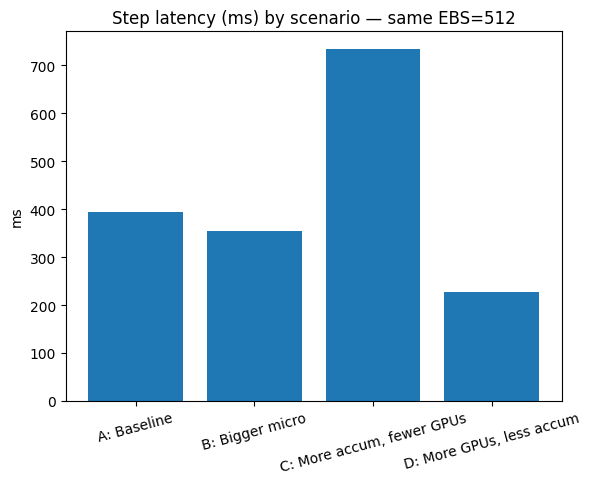

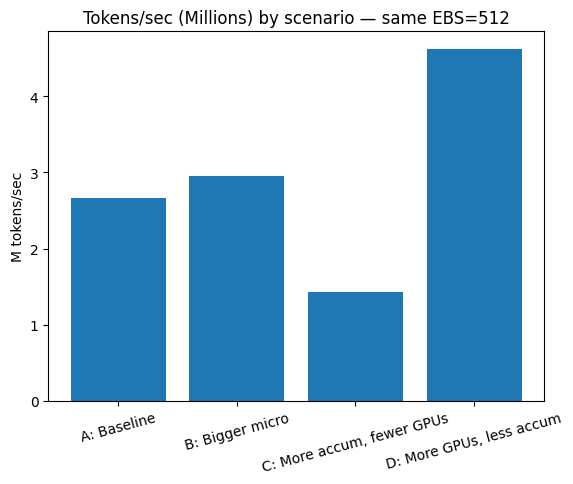

In [41]:
# Bar charts to visualize trade-offs
plt.figure()
plt.title('Step latency (ms) by scenario — same EBS=512')
plt.bar(df['scenario'], df['step_latency_ms'])
plt.xticks(rotation=15)
plt.ylabel('ms')
plt.show()

plt.figure()
plt.title('Tokens/sec (Millions) by scenario — same EBS=512')
plt.bar(df['scenario'], df['tokens_per_sec_M'])
plt.xticks(rotation=15)
plt.ylabel('M tokens/sec')
plt.show()

## What to notice
- **Same EBS ≠ same throughput**. You can reach 512 via different mixes, but **step latency** differs because:
  - Larger **micro-batches** better utilize the GPU kernels → **shorter per-micro-step compute**.
  - More **accumulation** means more micro-steps per update → **longer step latency** even with one sync.
  - More **GPUs** increases **sync cost** (roughly with `log2(dp)`).
- There’s a sweet spot: increase micro-batch until you get good utilization, use **just enough** accumulation to hit your EBS target, and don’t over-scale DP if sync cost dominates.
- Tie this back to Section 6: use the **best tokens/sec** scenario here to estimate your wall-clock and cost for a target token budget.

## 9. Regularization That Actually Helps — Overfit vs Ridge
**Quick guide**
- **What this does:** Fits high-degree polynomial features with and without L2 regularization.
- **What to observe:** OLS overfits (wiggly); Ridge smooths and lowers MSE. This is an illustration of the principle how adding weight decay can smoothen learning. To see an example to directly uses an LLM, refer to the Training _strategy_LLM_regularization notebook.
- **Why it matters:** Weight decay reduces variance on small/noisy data.

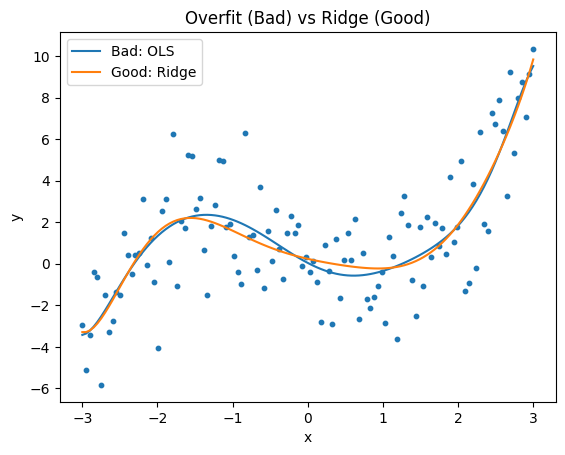

(3.678845312375614, 3.745934864340504)

In [43]:
import numpy as np, matplotlib.pyplot as plt
np.random.seed(0)
x = np.linspace(-3,3,120)
y_true = 0.5*x**3 - 2*x + 1
y = y_true + np.random.randn(*x.shape)*2.0
X = np.vstack([x**i for i in range(10)]).T
w_bad = np.linalg.pinv(X) @ y
yhat_bad = X @ w_bad
lam = 10.0
w_good = np.linalg.inv(X.T@X + lam*np.eye(X.shape[1])) @ X.T @ y
yhat_good = X @ w_good
plt.figure()
plt.title('Overfit (Bad) vs Ridge (Good)')
plt.scatter(x, y, s=10)
plt.plot(x, yhat_bad, label='Bad: OLS')
plt.plot(x, yhat_good, label='Good: Ridge')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()
mse_bad = float(np.mean((y - yhat_bad)**2))
mse_good = float(np.mean((y - yhat_good)**2))
mse_bad, mse_good

#### Deep dive — Regularization: Code walkthrough
- `X` stacks polynomial features up to degree 9; OLS (`pinv`) fits all coefficients freely, capturing noise.
- Ridge adds `λI` to `XᵀX` (L2 penalty), shrinking coefficients and smoothing predictions.
- Compare `mse_bad` vs `mse_good`; Ridge should be lower on average.

## 10. Label Smoothing — Soft Targets
**Quick guide**
- **What this does:** Transforms one-hot targets into softened distributions.
- **What to observe:** Label smoothing just makes the model a little less over-confident so it generalizes better: instead of betting 100% on one token, it spreads a tiny bit of probability to the others. In this cell, the “with smoothing” array (the second one) should look slightly less peaky and typically gives cleaner validation behavior than the no-smoothing baseline, which is shorter with higher numbers
- **Why it matters:** Often improves calibration, especially with noisy labels.

In [44]:
import numpy as np
def smooth(labels, n_classes=3, eps=0.05):
    out = np.full((len(labels), n_classes), eps/(n_classes-1))
    for i,lab in enumerate(labels):
        out[i, lab] = 1.0 - eps
    return out
hard = np.array([0,1,2,1,0])
soft = smooth(hard, 3, 0.1)
hard, soft

(array([0, 1, 2, 1, 0]),
 array([[0.9 , 0.05, 0.05],
        [0.05, 0.9 , 0.05],
        [0.05, 0.05, 0.9 ],
        [0.05, 0.9 , 0.05],
        [0.9 , 0.05, 0.05]]))

#### Deep dive — Label smoothing: Code walkthrough
- Initializes a matrix with `eps/(K-1)` then sets the true class to `1-eps`.
- This reduces gradient spikes and discourages extreme logits.
- Tune `eps` (e.g., 0.05–0.2); too large harms accuracy.

## 11. Early Stopping — Patience
**Quick guide**
- **What this does:** Stops when validation fails to improve for N evaluations.
- **What to observe:** `stop_at_eval` index where you'd halt training. Early stopping is just “quit while you’re ahead”: stop training when the validation metric stops improving so you don’t overfit and you save compute. In this cell, the point is that you keep the best validation checkpoint, not the final step, even if the training loss kept going down.
- **Why it matters:** Saves compute and prevents overfitting.

In [45]:
vals = [0.9,0.82,0.81,0.809,0.812,0.814,0.815,0.813,0.816]
best = min(vals)
patience=3
since = 0
stop_at=None
for i,v in enumerate(vals):
    if v < best:
        best=v; since=0
    else:
        since+=1
        if since>=patience:
            stop_at=i; break
print({'best_val':best,'stop_at_eval':stop_at})

{'best_val': 0.809, 'stop_at_eval': 2}


#### Deep dive — Early stopping: Code walkthrough
- Track `best`; increment `since` when no improvement; stop once `since ≥ patience`.
- In practice, checkpoint the **best** model and restore it after stopping.

## 12. Strategy Ladder — Choose the Lowest Rung That Works
**Quick guide**
- **What this does:** Encodes practical rules for when to use Prompt/RAG vs Adapters vs Full FT.
- **What to observe:** Recommends the simplest approach that meets requirements.
- **Why it matters:** Avoids unnecessary complexity and cost.

In [46]:
def choose_strategy(has_labels, facts_change_often, data_size, latency_tight):
    if facts_change_often:
        return 'Prompt + RAG (adapters later for formatting)'
    if not has_labels:
        return 'Prompting or Weak Supervision; consider Adapters when labels appear'
    if data_size in ('small','medium'):
        return 'Adapters (LoRA/QLoRA); escalate only if metric stalls'
    if data_size=='large' and not latency_tight:
        return 'Full FT if domain shift large; else Adapters + schedule tuning'
    return 'Adapters first; revisit after dev metric plateau'
print(choose_strategy(True, False, 'small', True))
print(choose_strategy(False, True, 'small', False))

Adapters (LoRA/QLoRA); escalate only if metric stalls
Prompt + RAG (adapters later for formatting)


#### Deep dive — Strategy selection: Code walkthrough
- Inputs: `has_labels`, `facts_change_often`, `data_size`, `latency_tight`.
- Logic favors freshness with RAG, minimal training with adapters for modest labeled data, and full FT only with large data and domain shift.
- Extend with constraints like privacy or on-device latency as needed.

## 13. Adapters (LoRA/QLoRA) — Guarded Code Stub
**Quick guide**
- **What this does:** Shows how to wrap a base model with LoRA adapters (if libs available).
- **What to observe:** Only target modules receive trainable low-rank updates.
- **Why it matters:** Achieves most of full FT quality at a fraction of the cost.

In [47]:
import importlib
HAS_TORCH = importlib.util.find_spec('torch') is not None
HAS_PEFT = importlib.util.find_spec('peft') is not None
if HAS_TORCH and HAS_PEFT:
    print('PEFT scaffolding example:')
    print('''\nfrom peft import LoraConfig, get_peft_model
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
base = 'gpt2'
tok = AutoTokenizer.from_pretrained(base)
model = AutoModelForCausalLM.from_pretrained(base)
cfg = LoraConfig(r=8, lora_alpha=16, target_modules=['q_proj','v_proj'], lora_dropout=0.05)
model = get_peft_model(model, cfg)
# Train as usual on your SFT pairs; save_adapter when done.
''')
else:
    print('PEFT not available in this environment; showing pseudocode only.')

PEFT scaffolding example:

from peft import LoraConfig, get_peft_model
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
base = 'gpt2'
tok = AutoTokenizer.from_pretrained(base)
model = AutoModelForCausalLM.from_pretrained(base)
cfg = LoraConfig(r=8, lora_alpha=16, target_modules=['q_proj','v_proj'], lora_dropout=0.05)
model = get_peft_model(model, cfg)
# Train as usual on your SFT pairs; save_adapter when done.



#### Deep dive — Adapters: Code walkthrough
- Guarded by availability of `torch` and `peft` so base runtime isn’t required.
- Loads a small base model and wraps attention projections (`q_proj`, `v_proj`) with low-rank adapters.
- Train adapters on SFT pairs; export adapter weights for portability.

## 14. Run-Log Template & Early-Stop Settings
**Quick guide**
- **What this does:** Appends an experiment row to a CSV run log.
- **What to observe:** A new line appears with config, EBS, LR, best metric, and next-step decision.
- **Why it matters:** Lightweight but powerful reproducibility aid.

In [49]:
import csv, os, time
RUNLOG = 'run_log_fully_annotated_v2.csv'
headers = ['date','config','EBS','LR','best_metric','decision','notes']
if not os.path.exists(RUNLOG):
    with open(RUNLOG,'w',newline='') as f:
        csv.writer(f).writerow(headers)
def log_run(config, ebs, lr, best_metric, decision, notes=''):
    with open(RUNLOG,'a',newline='') as f:
        csv.writer(f).writerow([
            time.strftime('%Y-%m-%d'), config, ebs, lr, best_metric, decision, notes
        ])
log_run('cfg_demo_lora_r8', 64, 2e-4, 'EM=88.1', 'Try LR=1.5e-4 next', 'dev set v1')
RUNLOG

'run_log_fully_annotated_v2.csv'

#### Deep dive — Experiment logging: Code walkthrough
- Creates the CSV with headers if missing; `log_run` appends one row per experiment.
- Keep this synced with your experiment tracker (e.g., add run IDs, dataset hashes).